In [ ]:
import pandas as pd
import glob

path = "topGlobal"

files = sorted(glob.glob(f"{path}/global*.csv"))

print("Archivos encontrados:", len(files))

if len(files) == 0:
    raise ValueError("❌ No se encontraron CSV en el path indicado")

dfs = []

for f in files:
    print("Leyendo:", f)
    tmp = pd.read_csv(f)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

Archivos encontrados: 10
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2016.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2017.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2018.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2019.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2020.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2021.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2022.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2023.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2024.csv
Leyendo: /Users/emiliahernandez/Desktop/desarrollo/topGlobal/global2025.csv


In [3]:
df

,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,source_file
0,1,spotify:track:5aAx2yezTd8zXrkmtKl66Z,"The Weeknd, Daft Punk",Starboy,The Weeknd/Lyric,1,-1,1,25286465,regional-global-weekly-2016-12-29.csv
1,2,spotify:track:7BKLCZ1jbUBVqRi2FVlTVw,"The Chainsmokers, Halsey",Closer,Disruptor Records/Columbia,2,-1,1,22047697,regional-global-weekly-2016-12-29.csv
2,3,spotify:track:5knuzwU65gJK7IF5yJsuaW,"Clean Bandit, Anne-Marie, Sean Paul",Rockabye (feat. Sean Paul & Anne-Marie),Atlantic Records UK,3,-1,1,19794482,regional-global-weekly-2016-12-29.csv
3,4,spotify:track:4pdPtRcBmOSQDlJ3Fk945m,"DJ Snake, Justin Bieber",Let Me Love You,DJ Snake Def Jam,4,-1,1,17965723,regional-global-weekly-2016-12-29.csv
4,5,spotify:track:5MFzQMkrl1FOOng9tq6R9r,"Maroon 5, Kendrick Lamar",Don't Wanna Know,Interscope Records*,5,-1,1,16966668,regional-global-weekly-2016-12-29.csv
...,...,...,...,...,...,...,...,...,...,...
93971,196,spotify:track:1k0JAiH11gHL9dc5dfQjQr,ILLIT,NOT CUTE ANYMORE,BELIFT LAB,161,161,4,9425843,regional-global-weekly-2025-12-25.csv
93972,197,spotify:track:1PREzVLuDT6PSE9sej4wnV,"Fuerza Regida, Grupo Frontera",COQUETA,Rancho Humilde/Streetmob Records/Grupo Fronter...,88,180,35,9414932,regional-global-weekly-2025-12-25.csv
93973,198,spotify:track:3nfxV3jfRcRWISwek49LTg,"Michael Bublé, The Puppini Sisters",Jingle Bells (feat. The Puppini Sisters),Reprise,136,-1,7,9380932,regional-global-weekly-2025-12-25.csv
93974,199,spotify:track:4hnzXzE7JiU5QAZFF9OUsI,"John Legend, Stevie Wonder",What Christmas Means to Me (feat. Stevie Wonder),Columbia/Legacy,199,-1,1,9351307,regional-global-weekly-2025-12-25.csv


In [4]:
df["date"] = pd.to_datetime(
    df["source_file"].str.extract(r"(\d{4}-\d{2}-\d{2})")[0]
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

df[["source_file","date"]].head()

,source_file,date
0,regional-global-weekly-2016-12-29.csv,2016-12-29
1,regional-global-weekly-2016-12-29.csv,2016-12-29
2,regional-global-weekly-2016-12-29.csv,2016-12-29
3,regional-global-weekly-2016-12-29.csv,2016-12-29
4,regional-global-weekly-2016-12-29.csv,2016-12-29


In [5]:
df["label_clean"] = (
    df["source"]
    .str.split("/")
    .str[0]
    .str.strip()
)

In [6]:
df

,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,source_file,date,year,month,label_clean
0,1,spotify:track:5aAx2yezTd8zXrkmtKl66Z,"The Weeknd, Daft Punk",Starboy,The Weeknd/Lyric,1,-1,1,25286465,regional-global-weekly-2016-12-29.csv,2016-12-29,2016,2016-12-01,The Weeknd
1,2,spotify:track:7BKLCZ1jbUBVqRi2FVlTVw,"The Chainsmokers, Halsey",Closer,Disruptor Records/Columbia,2,-1,1,22047697,regional-global-weekly-2016-12-29.csv,2016-12-29,2016,2016-12-01,Disruptor Records
2,3,spotify:track:5knuzwU65gJK7IF5yJsuaW,"Clean Bandit, Anne-Marie, Sean Paul",Rockabye (feat. Sean Paul & Anne-Marie),Atlantic Records UK,3,-1,1,19794482,regional-global-weekly-2016-12-29.csv,2016-12-29,2016,2016-12-01,Atlantic Records UK
3,4,spotify:track:4pdPtRcBmOSQDlJ3Fk945m,"DJ Snake, Justin Bieber",Let Me Love You,DJ Snake Def Jam,4,-1,1,17965723,regional-global-weekly-2016-12-29.csv,2016-12-29,2016,2016-12-01,DJ Snake Def Jam
4,5,spotify:track:5MFzQMkrl1FOOng9tq6R9r,"Maroon 5, Kendrick Lamar",Don't Wanna Know,Interscope Records*,5,-1,1,16966668,regional-global-weekly-2016-12-29.csv,2016-12-29,2016,2016-12-01,Interscope Records*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93971,196,spotify:track:1k0JAiH11gHL9dc5dfQjQr,ILLIT,NOT CUTE ANYMORE,BELIFT LAB,161,161,4,9425843,regional-global-weekly-2025-12-25.csv,2025-12-25,2025,2025-12-01,BELIFT LAB
93972,197,spotify:track:1PREzVLuDT6PSE9sej4wnV,"Fuerza Regida, Grupo Frontera",COQUETA,Rancho Humilde/Streetmob Records/Grupo Fronter...,88,180,35,9414932,regional-global-weekly-2025-12-25.csv,2025-12-25,2025,2025-12-01,Rancho Humilde
93973,198,spotify:track:3nfxV3jfRcRWISwek49LTg,"Michael Bublé, The Puppini Sisters",Jingle Bells (feat. The Puppini Sisters),Reprise,136,-1,7,9380932,regional-global-weekly-2025-12-25.csv,2025-12-25,2025,2025-12-01,Reprise
93974,199,spotify:track:4hnzXzE7JiU5QAZFF9OUsI,"John Legend, Stevie Wonder",What Christmas Means to Me (feat. Stevie Wonder),Columbia/Legacy,199,-1,1,9351307,regional-global-weekly-2025-12-25.csv,2025-12-25,2025,2025-12-01,Columbia


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================
# LOAD DATA
# =============================

charts = df.copy()   # your weekly top200 df
artists = pd.read_csv(
    "/Users/emiliahernandez/Desktop/desarrollo/Proyetco/unique_artists.csv",
    encoding="latin1"
)


# clean artist names
charts["artist_names"] = charts["artist_names"].str.lower()
artists["artist_name"] = artists["artist_name"].str.lower()

# =============================
# EXPLODE MULTI-ARTIST TRACKS
# =============================

charts["artist_names"] = charts["artist_names"].str.split(",")
charts = charts.explode("artist_names")
charts["artist_names"] = charts["artist_names"].str.strip()

In [8]:
import pandas as pd

artists = pd.read_csv(
    "/Users/emiliahernandez/Desktop/desarrollo/Proyetco/unique_artists.csv",
    encoding="latin1"
)

# lowercase + strip para TODO objeto/string
for c in artists.select_dtypes(include="object").columns:
    artists[c] = artists[c].str.strip().str.lower()

artists.head()


,artist_name,country,lgbtq+,gay_icon,black,latino,gender,act_type,primary_language
0,$not,usa,no,no,no,no,male,solo,english
1,$uicideboy$,usa,no,no,no,no,male,duo,english
2,nsync,usa,yes,no,no,no,male,band,english
3,.feast,unknown,unknown,no,unknown,unknown,unknown,group,unknown
4,070 shake,usa,yes,no,yes,yes,female,solo,english


In [9]:
artists.columns


Index(['artist_name', 'country', 'lgbtq+', 'gay_icon', 'black', 'latino',
       'gender', 'act_type', 'primary_language'],
      dtype='object')

In [10]:
cols_to_check = [
    "latino",
    "black",
    "lgbtq_icon",
    "gender",
    "act_type",
    "primary_language",
    "country"
]

for c in cols_to_check:
    if c in artists.columns:
        print("\n", c.upper())
        print(artists[c].value_counts(dropna=False))



 LATINO
latino
no                        1705
yes                        629
unknown                     22
yes (turkish descent)        2
ñ                            2
yes (turkish heritage)       1
NaN                          1
Name: count, dtype: int64

 BLACK
black
no            1797
yes            502
mixed           34
unknown         25
ñ                2
NaN              1
indigenous       1
Name: count, dtype: int64

 GENDER
gender
male          1740
female         496
mixed           89
NaN             12
nonbinary        9
group            8
duo              3
unknown          2
fictional        2
female-led       1
Name: count, dtype: int64

 ACT_TYPE
act_type
solo             1939
duo               132
band              128
group             128
label               6
soundtrack          4
cast                4
company             3
fictional           3
collective          3
choir               3
franchise           2
ensemble            2
solo/band           1
project 

## Limpiar artists


In [11]:
import numpy as np
import re

# ============================
# BASIC NORMALIZATION AGAIN
# ============================

for c in artists.select_dtypes(include="object").columns:
    artists[c] = artists[c].str.strip().str.lower()

# ============================
# LATINO
# ============================

artists["latino_clean"] = artists["latino"]

artists["latino_clean"] = (
    artists["latino_clean"]
    .replace({
        "yes (turkish descent)": "yes",
        "yes (turkish heritage)": "yes",
        "ñ": np.nan,
        "unknown": np.nan
    })
)

artists["latino_clean"] = artists["latino_clean"].where(
    artists["latino_clean"].isin(["yes", "no"])
)

# ============================
# BLACK
# ============================

artists["black_clean"] = artists["black"]

artists["black_clean"] = (
    artists["black_clean"]
    .replace({
        "mixed": "yes",
        "indigenous": np.nan,
        "ñ": np.nan,
        "unknown": np.nan
    })
)

artists["black_clean"] = artists["black_clean"].where(
    artists["black_clean"].isin(["yes", "no"])
)

# ============================
# GENDER
# ============================

artists["gender_clean"] = artists["gender"]

artists["gender_clean"] = (
    artists["gender_clean"]
    .replace({
        "female-led": "female",
        "duo": "group",
        "fictional": "unknown"
    })
)

artists["gender_clean"] = artists["gender_clean"].where(
    artists["gender_clean"].isin(
        ["male", "female", "mixed", "nonbinary", "group", "unknown"]
    )
)

# ============================
# ACT TYPE
# ============================

artists["act_type_clean"] = artists["act_type"]

artists["act_type_clean"] = artists["act_type_clean"].replace({
    "solo/band": "group",
    "ensemble": "group",
    "collective": "group",
    "virtual group": "group",
    "trio": "group",
    "project": "group",
    "choir": "group",
    "franchise": "group",
    "cast": "group",
    "soundtrack": "group",
    "character": "fictional",
    "company": "company",
    "label": "company"
})

# ============================
# PRIMARY LANGUAGE
# ============================

def clean_language(x):
    if pd.isna(x):
        return x

    if "/" in x:
        return "multilingual"

    if " / " in x:
        return "multilingual"

    if x in ["english/spanish", "spanish/english"]:
        return "multilingual"

    if x == "unknown":
        return np.nan

    return x


artists["primary_language_clean"] = artists["primary_language"].apply(clean_language)

# ============================
# COUNTRY (optional: simplify combos)
# ============================

artists["country_clean"] = artists["country"].apply(
    lambda x: "multiple" if isinstance(x, str) and "/" in x else x
)

# ============================
# CHECK RESULTS
# ============================

cols_check = [
    "latino_clean",
    "black_clean",
    "gender_clean",
    "act_type_clean",
    "primary_language_clean",
    "country_clean"
]

for c in cols_check:
    print("\n", c.upper())
    print(artists[c].value_counts(dropna=False))



 LATINO_CLEAN
latino_clean
no     1705
yes     632
NaN      25
Name: count, dtype: int64

 BLACK_CLEAN
black_clean
no     1797
yes     536
NaN      29
Name: count, dtype: int64

 GENDER_CLEAN
gender_clean
male         1740
female        497
mixed          89
NaN            12
group          11
nonbinary       9
unknown         4
Name: count, dtype: int64

 ACT_TYPE_CLEAN
act_type_clean
solo         1939
group         150
duo           132
band          128
company         9
fictional       4
Name: count, dtype: int64

 PRIMARY_LANGUAGE_CLEAN
primary_language_clean
english         1369
spanish          381
portuguese       213
german            67
korean            55
hindi             52
italian           45
french            36
multilingual      26
indonesian        15
turkish           15
punjabi           13
instrumental      10
dutch              9
japanese           8
romanian           5
urdu               5
ukrainian          3
swedish            3
zulu               3
tamil   

/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/3650492095.py:97: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(complete_weeks)


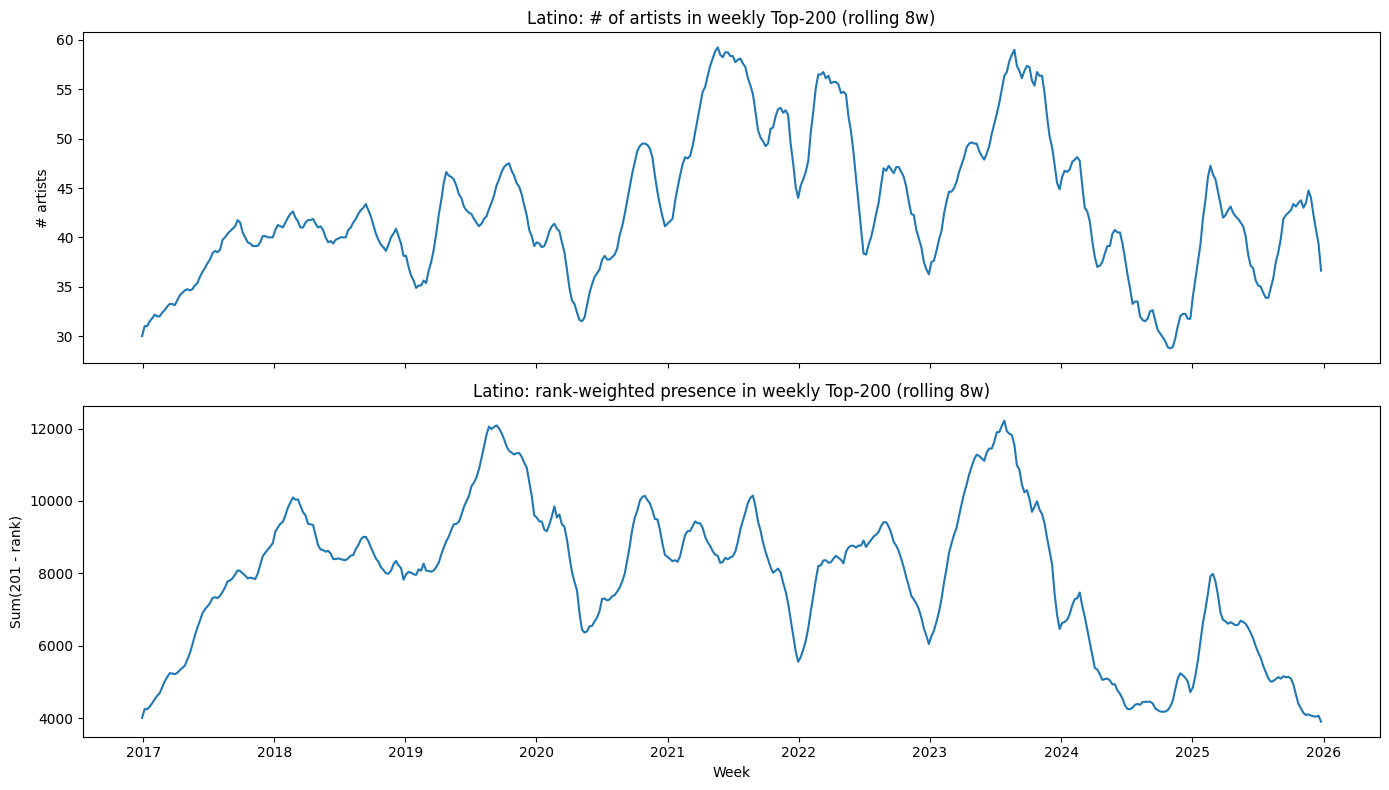

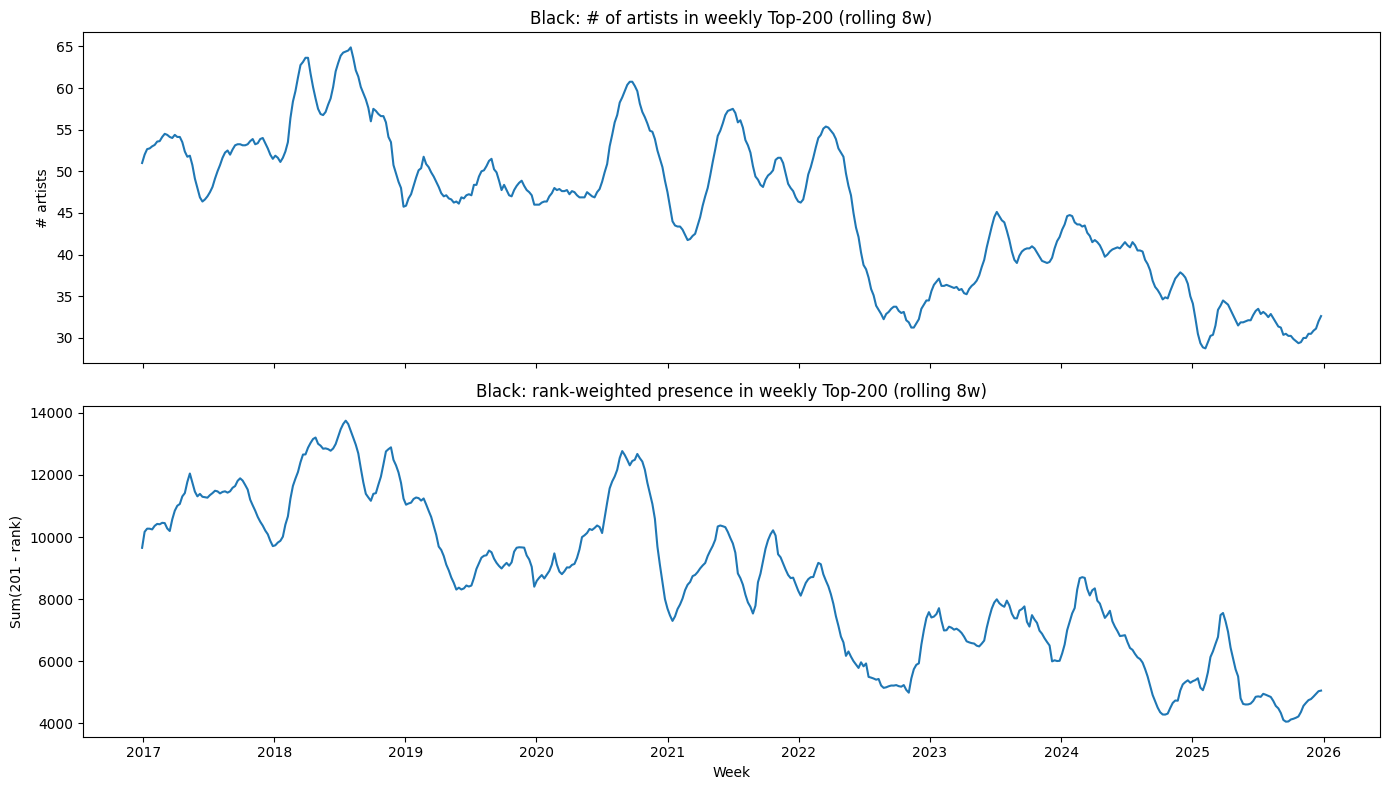

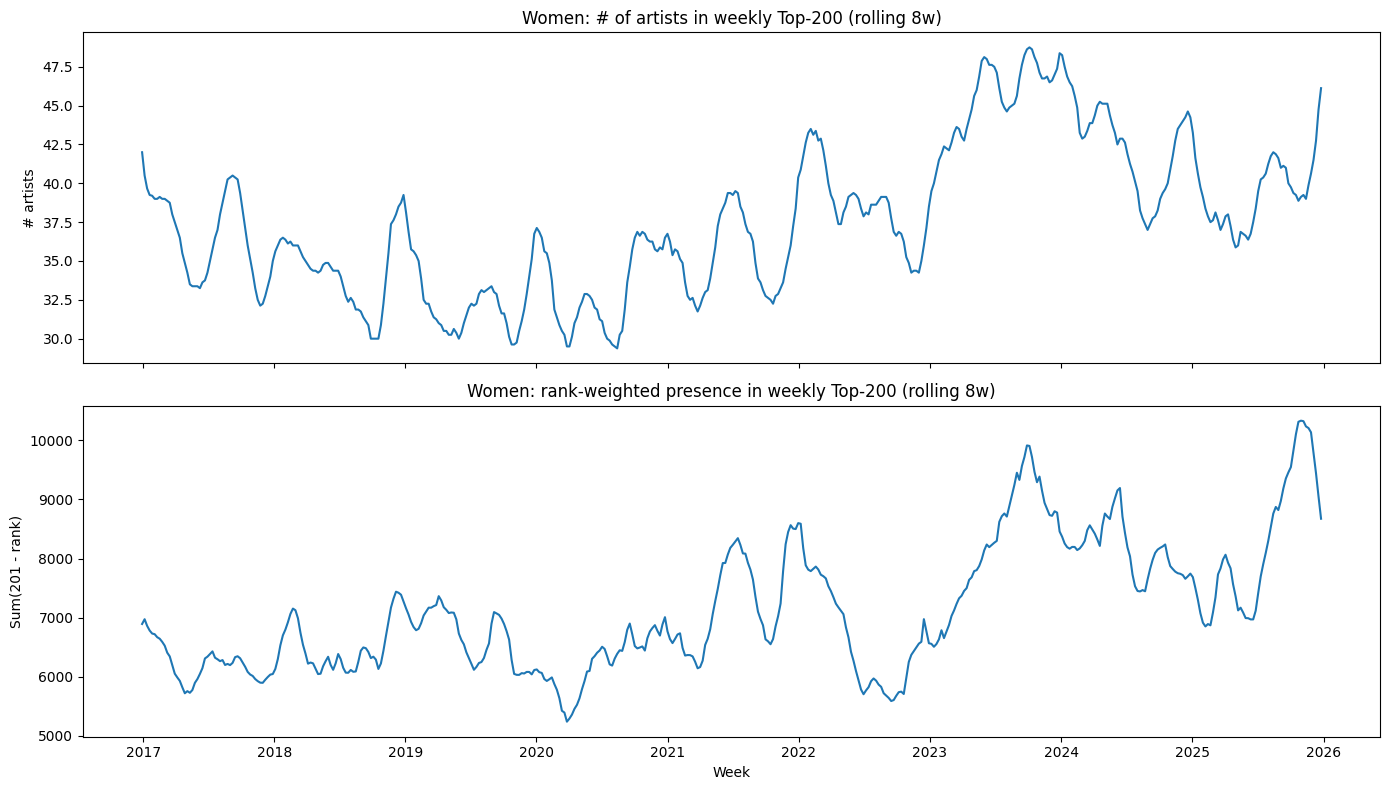

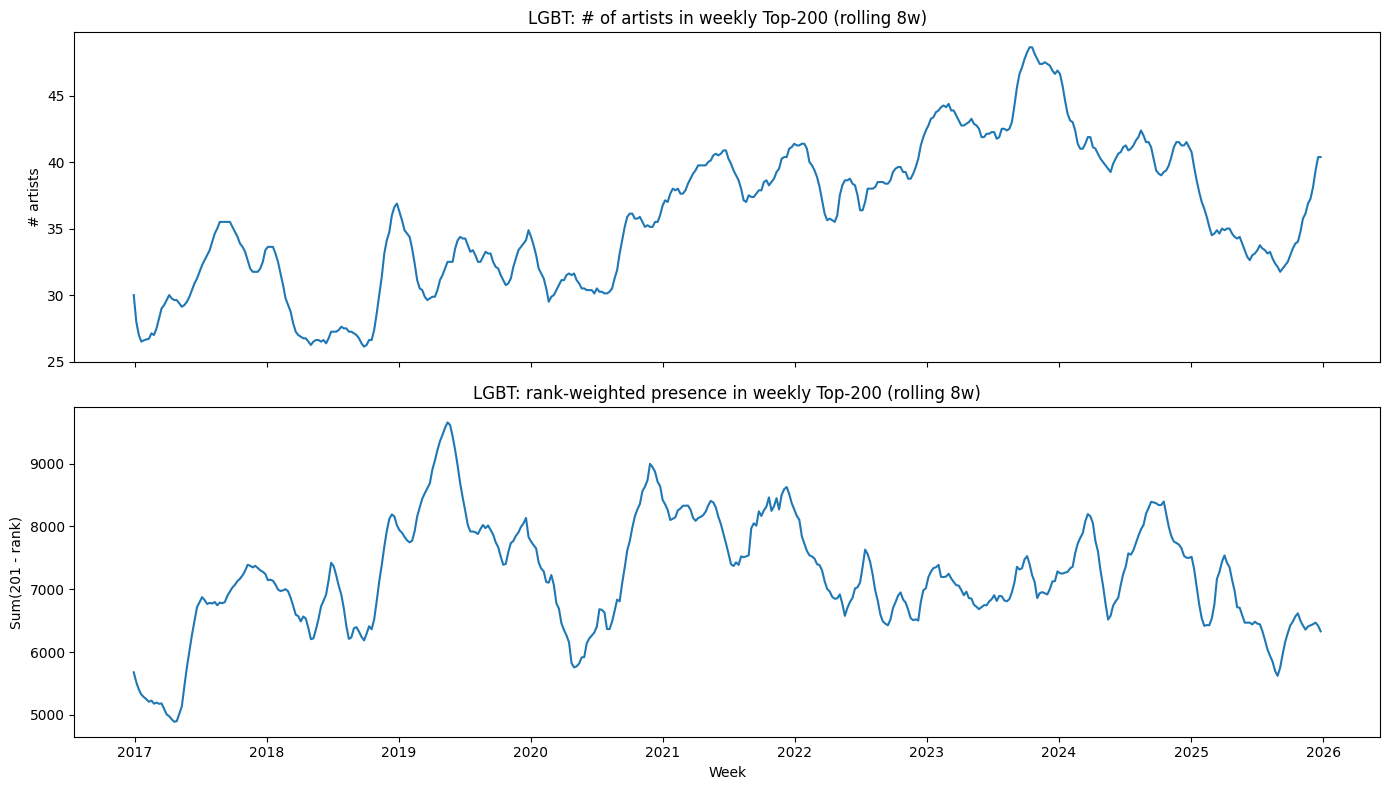

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS (you already have `df` = weekly top200 data)
# ============================================================
charts = df.copy()

# If you haven’t loaded/cleaned artists yet, do it first (your cleaned artists df must exist as `artists`)
# artists must contain: artist_name, latino_clean, black_clean, gender_clean, gay_icon (or whatever your LGBT col is)

# ============================================================
# 1) Normalize + explode multi-artist tracks
# ============================================================
charts["date"] = pd.to_datetime(charts["date"])
charts["artist_names"] = charts["artist_names"].astype(str).str.lower()

# split on comma (your data uses "The Weeknd, Daft Punk")
charts["artist_names"] = charts["artist_names"].str.split(",")
charts = charts.explode("artist_names")
charts["artist_names"] = charts["artist_names"].str.strip()

# ============================================================
# 2) Merge artist metadata
# ============================================================
artists["artist_name"] = artists["artist_name"].astype(str).str.lower().str.strip()

merged = charts.merge(
    artists,
    left_on="artist_names",
    right_on="artist_name",
    how="left"
)

# ============================================================
# 3) Rank weights (higher rank => more weight)
# ============================================================
merged["rank"] = pd.to_numeric(merged["rank"], errors="coerce")
merged["rank_weight"] = 201 - merged["rank"]  # rank 1 -> 200, rank 200 -> 1

# ============================================================
# 4) Helper to compute weekly stats for a group
#    - count: # unique artists in that minority that week
#    - weighted: sum of rank weights for those artists that week
# ============================================================
def weekly_stats(mask, group_name):
    tmp = merged[mask].copy()

    # count unique artists per week
    count = (
        tmp.groupby("date")["artist_name"]
        .nunique()
        .rename("count")
    )

    # weighted presence per week
    weighted = (
        tmp.groupby("date")["rank_weight"]
        .sum(min_count=1)
        .rename("weighted")
    )

    out = pd.concat([count, weighted], axis=1).reset_index()
    out["group"] = group_name
    return out

# ============================================================
# 5) Define minority masks (adjust LGBT column name here!)
# ============================================================
# --- pick your LGBT column name:
LGBT_COL = "gay_icon"  # change to "lgbtq_icon_clean" etc if your file uses a different name

minorities = {
    "Latino": (merged["latino_clean"] == "yes"),
    "Black": (merged["black_clean"] == "yes"),
    "Women": (merged["gender_clean"] == "female"),
    "LGBT": (merged[LGBT_COL].astype(str).str.lower().str.strip() == "yes")
}

# ============================================================
# 6) Build stats and (optionally) fill missing weeks with 0
# ============================================================
all_stats = pd.concat([weekly_stats(mask, name) for name, mask in minorities.items()], ignore_index=True)

# Create full weekly date index so lines don’t “break” if a group is absent in a week
all_weeks = pd.DataFrame({"date": pd.date_range(merged["date"].min(), merged["date"].max(), freq="W-THU")})

def complete_weeks(gdf):
    out = all_weeks.merge(gdf, on="date", how="left")
    out["group"] = gdf["group"].iloc[0]
    out[["count", "weighted"]] = out[["count", "weighted"]].fillna(0)
    return out

all_stats = (
    all_stats.groupby("group", group_keys=False)
    .apply(complete_weeks)
    .reset_index(drop=True)
)

# ============================================================
# 7) Plotting: 2 graphs per minority (count + weighted)
# ============================================================
def plot_two_panels(stats_df, group_name, smooth_weeks=8):
    sub = stats_df[stats_df["group"] == group_name].sort_values("date").copy()

    # Optional smoothing (rolling mean)
    sub["count_s"] = sub["count"].rolling(smooth_weeks, min_periods=1).mean()
    sub["weighted_s"] = sub["weighted"].rolling(smooth_weeks, min_periods=1).mean()

    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # COUNT
    ax[0].plot(sub["date"], sub["count_s"])
    ax[0].set_title(f"{group_name}: # of artists in weekly Top-200 (rolling {smooth_weeks}w)")
    ax[0].set_ylabel("# artists")

    # WEIGHTED
    ax[1].plot(sub["date"], sub["weighted_s"])
    ax[1].set_title(f"{group_name}: rank-weighted presence in weekly Top-200 (rolling {smooth_weeks}w)")
    ax[1].set_ylabel("Sum(201 - rank)")
    ax[1].set_xlabel("Week")

    plt.tight_layout()
    plt.show()

for g in minorities.keys():
    plot_two_panels(all_stats, g, smooth_weeks=8)


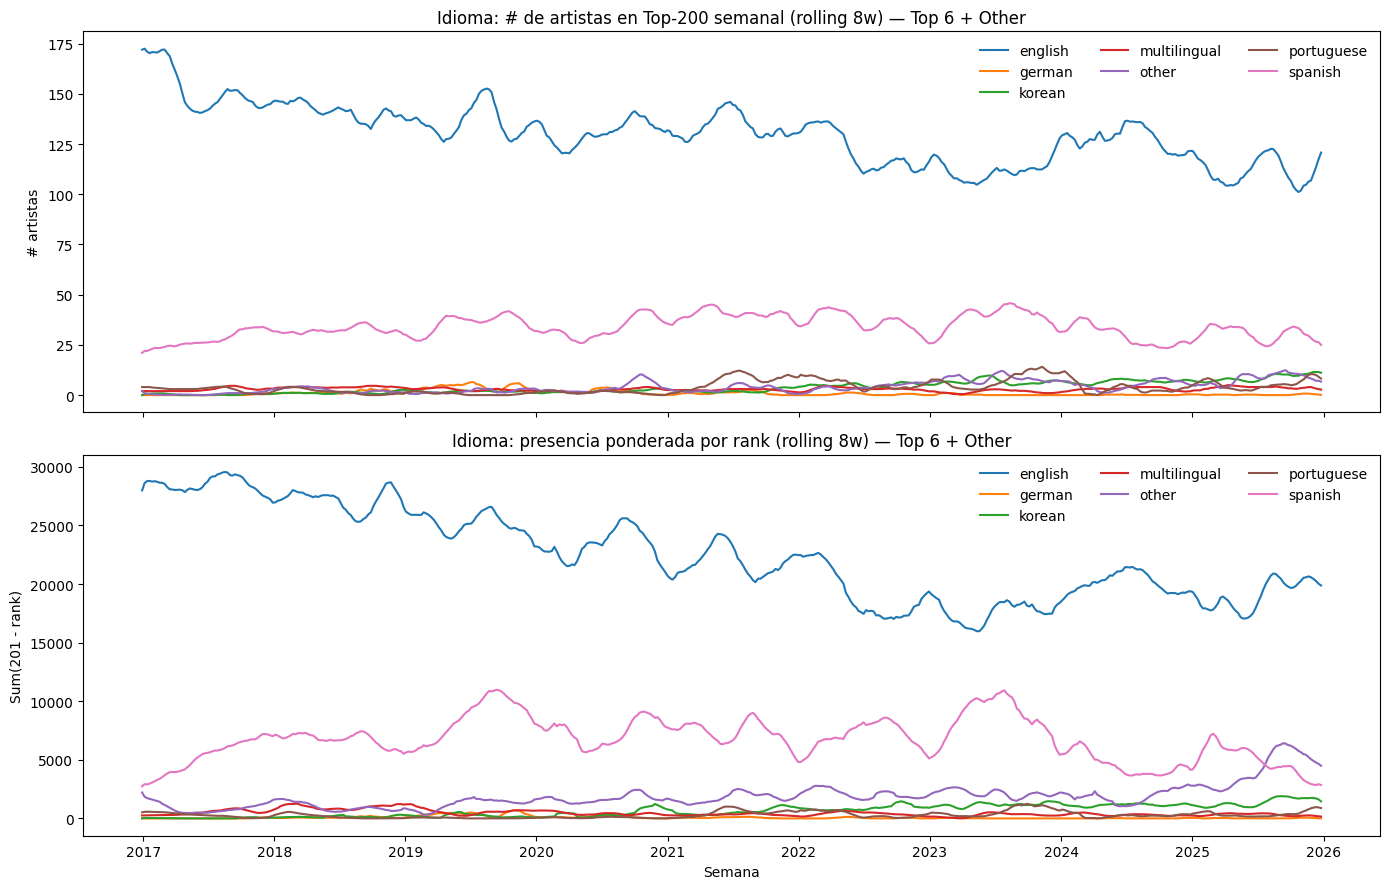

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) Base
# ----------------------------
charts = df.copy()
charts["date"] = pd.to_datetime(charts["date"])
charts["artist_names"] = charts["artist_names"].astype(str).str.lower()

# explode artistas por track
charts["artist_names"] = charts["artist_names"].str.split(",")
charts = charts.explode("artist_names")
charts["artist_names"] = charts["artist_names"].str.strip()

# merge con metadata
artists["artist_name"] = artists["artist_name"].astype(str).str.lower().str.strip()

m = charts.merge(
    artists[["artist_name", "primary_language_clean"]],
    left_on="artist_names",
    right_on="artist_name",
    how="left"
)

# rank weight
m["rank"] = pd.to_numeric(m["rank"], errors="coerce")
m["rank_weight"] = 201 - m["rank"]

# si falta idioma, lo marcamos
m["primary_language_clean"] = m["primary_language_clean"].fillna("unknown")

# ----------------------------
# 1) Elegir top N idiomas (por frecuencia)
# ----------------------------
TOP_N = 6  # cambia si quieres
top_langs = (
    m.loc[m["primary_language_clean"] != "unknown", "primary_language_clean"]
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)

m["lang_group"] = np.where(
    m["primary_language_clean"].isin(top_langs),
    m["primary_language_clean"],
    "other"
)

# ----------------------------
# 2) Stats semanales por idioma:
#    count = # artistas únicos en ese idioma esa semana
#    weighted = suma de pesos (201-rank)
# ----------------------------
weekly = (
    m.groupby(["date", "lang_group"])
     .agg(
         count=("artist_name", "nunique"),
         weighted=("rank_weight", "sum")
     )
     .reset_index()
)

# completar semanas para que no se rompa la línea
all_weeks = pd.DataFrame({"date": pd.date_range(m["date"].min(), m["date"].max(), freq="W-THU")})
all_langs = pd.DataFrame({"lang_group": sorted(weekly["lang_group"].unique())})

grid = all_weeks.merge(all_langs, how="cross")
weekly = grid.merge(weekly, on=["date", "lang_group"], how="left").fillna({"count": 0, "weighted": 0})

# ----------------------------
# 3) Plot: COUNT (líneas) + WEIGHTED (líneas)
# ----------------------------
def plot_lang_panels(weekly_df, smooth_weeks=8):
    d = weekly_df.sort_values("date").copy()

    # smoothing
    d["count_s"] = d.groupby("lang_group")["count"].transform(lambda s: s.rolling(smooth_weeks, 1).mean())
    d["weighted_s"] = d.groupby("lang_group")["weighted"].transform(lambda s: s.rolling(smooth_weeks, 1).mean())

    fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    for lg in sorted(d["lang_group"].unique()):
        sub = d[d["lang_group"] == lg]
        ax[0].plot(sub["date"], sub["count_s"], label=lg)
        ax[1].plot(sub["date"], sub["weighted_s"], label=lg)

    ax[0].set_title(f"Idioma: # de artistas en Top-200 semanal (rolling {smooth_weeks}w) — Top {TOP_N} + Other")
    ax[0].set_ylabel("# artistas")
    ax[0].legend(ncol=3, frameon=False)

    ax[1].set_title(f"Idioma: presencia ponderada por rank (rolling {smooth_weeks}w) — Top {TOP_N} + Other")
    ax[1].set_ylabel("Sum(201 - rank)")
    ax[1].set_xlabel("Semana")
    ax[1].legend(ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()

plot_lang_panels(weekly, smooth_weeks=8)


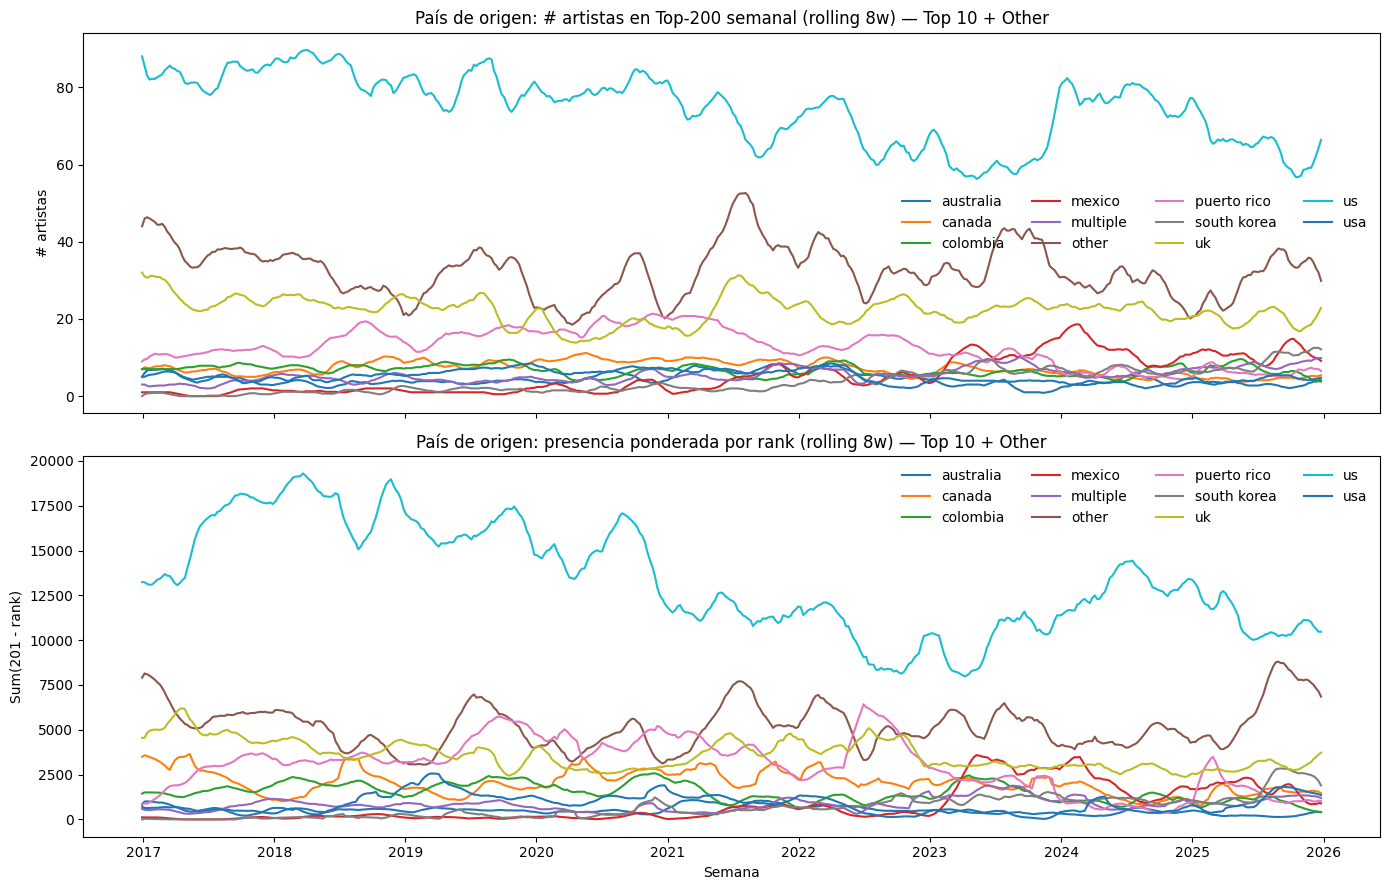

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) Base (charts + merge)
# ----------------------------
charts = df.copy()
charts["date"] = pd.to_datetime(charts["date"])
charts["artist_names"] = charts["artist_names"].astype(str).str.lower()

charts["artist_names"] = charts["artist_names"].str.split(",")
charts = charts.explode("artist_names")
charts["artist_names"] = charts["artist_names"].str.strip()

artists["artist_name"] = artists["artist_name"].astype(str).str.lower().str.strip()

m = charts.merge(
    artists[["artist_name", "country_clean"]],
    left_on="artist_names",
    right_on="artist_name",
    how="left"
)

m["rank"] = pd.to_numeric(m["rank"], errors="coerce")
m["rank_weight"] = 201 - m["rank"]

m["country_clean"] = m["country_clean"].fillna("unknown")

# ----------------------------
# 1) Top N countries + other
# ----------------------------
TOP_N = 10  # ajusta
top_countries = (
    m.loc[m["country_clean"].isin(["unknown"]) == False, "country_clean"]
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)

m["country_group"] = np.where(
    m["country_clean"].isin(top_countries),
    m["country_clean"],
    "other"
)

# ----------------------------
# 2) Weekly stats
# ----------------------------
weekly = (
    m.groupby(["date", "country_group"])
     .agg(
         count=("artist_name", "nunique"),
         weighted=("rank_weight", "sum")
     )
     .reset_index()
)

# completar semanas y grupos para líneas continuas
all_weeks = pd.DataFrame({"date": pd.date_range(m["date"].min(), m["date"].max(), freq="W-THU")})
all_groups = pd.DataFrame({"country_group": sorted(weekly["country_group"].unique())})

grid = all_weeks.merge(all_groups, how="cross")
weekly = grid.merge(weekly, on=["date", "country_group"], how="left").fillna({"count": 0, "weighted": 0})

# ----------------------------
# 3) Plot (2 paneles)
# ----------------------------
def plot_country_panels(weekly_df, smooth_weeks=8):
    d = weekly_df.sort_values("date").copy()

    d["count_s"] = d.groupby("country_group")["count"].transform(lambda s: s.rolling(smooth_weeks, 1).mean())
    d["weighted_s"] = d.groupby("country_group")["weighted"].transform(lambda s: s.rolling(smooth_weeks, 1).mean())

    fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    for cg in sorted(d["country_group"].unique()):
        sub = d[d["country_group"] == cg]
        ax[0].plot(sub["date"], sub["count_s"], label=cg)
        ax[1].plot(sub["date"], sub["weighted_s"], label=cg)

    ax[0].set_title(f"País de origen: # artistas en Top-200 semanal (rolling {smooth_weeks}w) — Top {TOP_N} + Other")
    ax[0].set_ylabel("# artistas")
    ax[0].legend(ncol=4, frameon=False)

    ax[1].set_title(f"País de origen: presencia ponderada por rank (rolling {smooth_weeks}w) — Top {TOP_N} + Other")
    ax[1].set_ylabel("Sum(201 - rank)")
    ax[1].set_xlabel("Semana")
    ax[1].legend(ncol=4, frameon=False)

    plt.tight_layout()
    plt.show()

plot_country_panels(weekly, smooth_weeks=8)


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/540506172.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


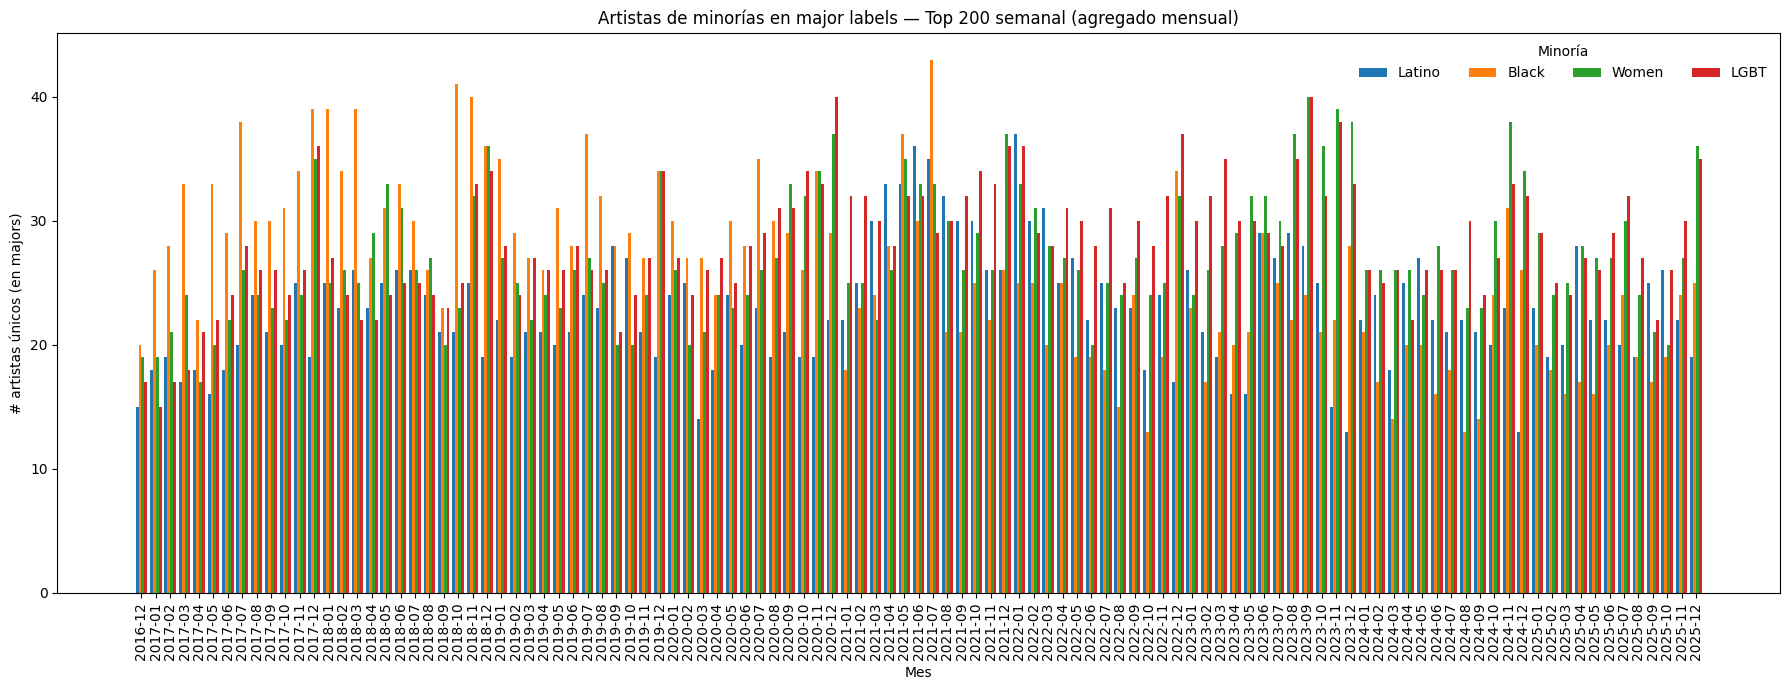


--- SANITY CHECKS ---
Rows in charts: 148389
Rows in merged: 150810
Rows in majors: 69011
Share majors: 45.87 %

Merge coverage (artist metadata present):
pct non-null latino_clean: 94.59 %
pct non-null black_clean : 93.99 %
pct non-null gender_clean: 95.16 %

Minority counts overall in majors (unique artists):
Latino: 230
Black : 289
Women : 287
LGBT  : 168


In [15]:
majors_kw = [
    # ---- UNIVERSAL ----
    "universal", "umg", "interscope", "republic", "island", "def jam",
    "capitol", "motown", "polydor", "virgin", "emi", "geffen",
    "astralwerks", "fonovisa", "machete", "loma vista", "darkroom",

    # ---- SONY ----
    "sony", "columbia", "rca", "epic", "arista", "jive", "legacy",
    "masterworks",

    # ---- WARNER ----
    "warner", "atlantic", "elektra", "parlophone", "reprise",
    "rhino", "wea", "fueled by ramen", "xl recordings",

    # ---- K-POP BIG ----
    "hybe", "bighit", "ador", "pledis", "koz", "sm entertainment",
    "starship", "yg entertainment",

    # ---- OTHER GLOBAL GIANTS ----
    "t-series", "t series", "disney", "hollywood records",
    "walt disney", "marvel", "riot games", "lions gate",
    "red bull records", "ministry of sound", "saregama",

    # ---- DISTRIBUTION CLAUSE ----
    "under exclusive license to",
    "distributed through",
    "powered by"
]

def is_major(label):
    s = str(label).lower()
    return any(k in s for k in majors_kw)

charts["is_major"] = charts["label_clean"].apply(is_major)

# ============================================================
# 4) Merge charts with artists metadata
# ============================================================
artists["artist_name"] = artists["artist_name"].astype(str).str.lower().str.strip()

merged = charts.merge(
    artists,
    left_on="artist_names",
    right_on="artist_name",
    how="left"
)

# ============================================================
# 5) Filter majors + month bucket
# ============================================================
maj = merged[merged["is_major"]].copy()
maj = maj.dropna(subset=["date"])

maj["month"] = maj["date"].dt.to_period("M").dt.to_timestamp()

# ============================================================
# 6) Minority flags
# ============================================================
# If your LGBT column has a different name, change this:
LGBT_COL = "gay_icon"

# Make sure flags are boolean even with missing values
maj["latino_flag"] = maj["latino_clean"].eq("yes")
maj["black_flag"]  = maj["black_clean"].eq("yes")
maj["women_flag"]  = maj["gender_clean"].eq("female")

if LGBT_COL in maj.columns:
    maj["lgbt_flag"] = maj[LGBT_COL].astype(str).str.lower().str.strip().eq("yes")
else:
    # fallback: create empty flag so code runs
    maj["lgbt_flag"] = False
    print(f"WARNING: '{LGBT_COL}' not found in artists. Set maj['lgbt_flag']=False. Change LGBT_COL to your actual column name.")

# ============================================================
# 7) Monthly unique-artist counts in majors
# ============================================================
monthly = (
    maj.groupby("month")
       .apply(lambda g: pd.Series({
           "Latino": g.loc[g["latino_flag"], "artist_name"].nunique(),
           "Black":  g.loc[g["black_flag"],  "artist_name"].nunique(),
           "Women":  g.loc[g["women_flag"],  "artist_name"].nunique(),
           "LGBT":   g.loc[g["lgbt_flag"],   "artist_name"].nunique(),
       }))
       .reset_index()
       .sort_values("month")
)

monthly_long = monthly.melt(
    id_vars="month",
    var_name="minority",
    value_name="artists"
)

# ============================================================
# 8) Plot: grouped bars (NOT stacked)
# ============================================================
months = monthly["month"].tolist()
minorities = ["Latino", "Black", "Women", "LGBT"]

x = np.arange(len(months))
width = 0.20

fig, ax = plt.subplots(figsize=(18, 7))

for i, grp in enumerate(minorities):
    sub = monthly_long[monthly_long["minority"] == grp].set_index("month").reindex(months).reset_index()
    ax.bar(x + i*width, sub["artists"].fillna(0), width, label=grp)

ax.set_xticks(x + width * (len(minorities)-1)/2)
ax.set_xticklabels([pd.to_datetime(d).strftime("%Y-%m") for d in months], rotation=90)

ax.set_title("Artistas de minorías en major labels — Top 200 semanal (agregado mensual)")
ax.set_xlabel("Mes")
ax.set_ylabel("# artistas únicos (en majors)")
ax.legend(title="Minoría", ncol=4, frameon=False)

plt.tight_layout()
plt.show()

# ============================================================
# 9) Quick sanity checks (to debug 'Latinos not appearing')
# ============================================================
print("\n--- SANITY CHECKS ---")
print("Rows in charts:", len(charts))
print("Rows in merged:", len(merged))
print("Rows in majors:", len(maj))
print("Share majors:", round(charts['is_major'].mean()*100, 2), "%")

print("\nMerge coverage (artist metadata present):")
print("pct non-null latino_clean:", round(maj["latino_clean"].notna().mean()*100, 2), "%")
print("pct non-null black_clean :", round(maj["black_clean"].notna().mean()*100, 2), "%")
print("pct non-null gender_clean:", round(maj["gender_clean"].notna().mean()*100, 2), "%")

print("\nMinority counts overall in majors (unique artists):")
print("Latino:", maj.loc[maj["latino_flag"], "artist_name"].nunique())
print("Black :", maj.loc[maj["black_flag"],  "artist_name"].nunique())
print("Women :", maj.loc[maj["women_flag"],  "artist_name"].nunique())
print("LGBT  :", maj.loc[maj["lgbt_flag"],   "artist_name"].nunique())

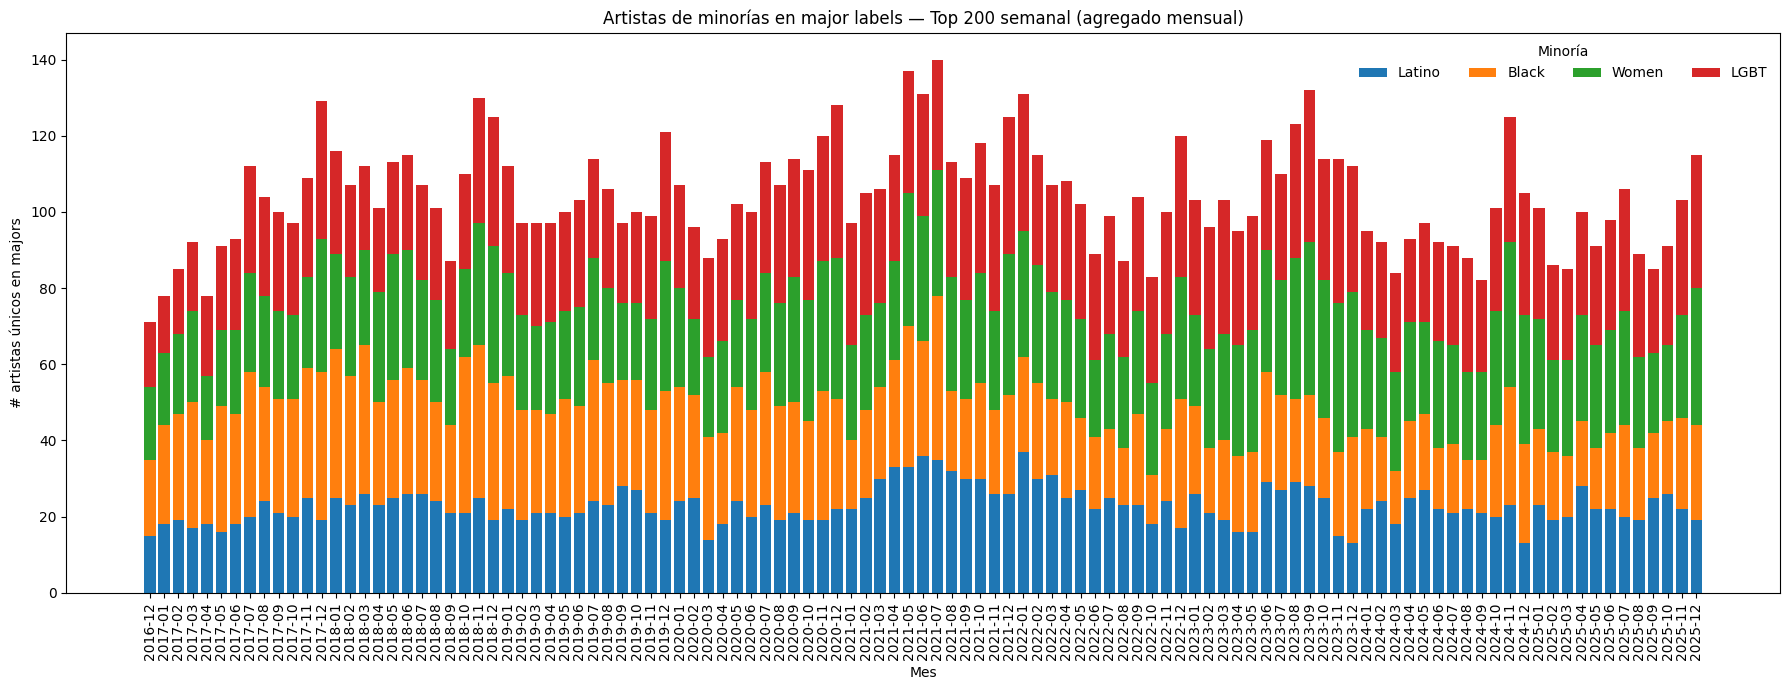

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# monthly tiene columnas:
# month | Latino | Black | Women | LGBT

monthly_plot = monthly.sort_values("month").copy()

x = np.arange(len(monthly_plot))

fig, ax = plt.subplots(figsize=(18, 7))

bottom = np.zeros(len(monthly_plot))

colors = {
    "Latino": "#1f77b4",
    "Black": "#ff7f0e",
    "Women": "#2ca02c",
    "LGBT": "#d62728",
}

for grp in ["Latino", "Black", "Women", "LGBT"]:
    ax.bar(
        x,
        monthly_plot[grp],
        bottom=bottom,
        label=grp,
        color=colors[grp]
    )
    bottom += monthly_plot[grp].values

ax.set_xticks(x)
ax.set_xticklabels(
    [pd.to_datetime(d).strftime("%Y-%m") for d in monthly_plot["month"]],
    rotation=90
)

ax.set_title("Artistas de minorías en major labels — Top 200 semanal (agregado mensual)")
ax.set_xlabel("Mes")
ax.set_ylabel("# artistas únicos en majors")

ax.legend(title="Minoría", ncol=4, frameon=False)

plt.tight_layout()
plt.show()


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/3059510187.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/3059510187.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
/var/folders/5x/v_n3jdfd003f7mqj3m9j1k

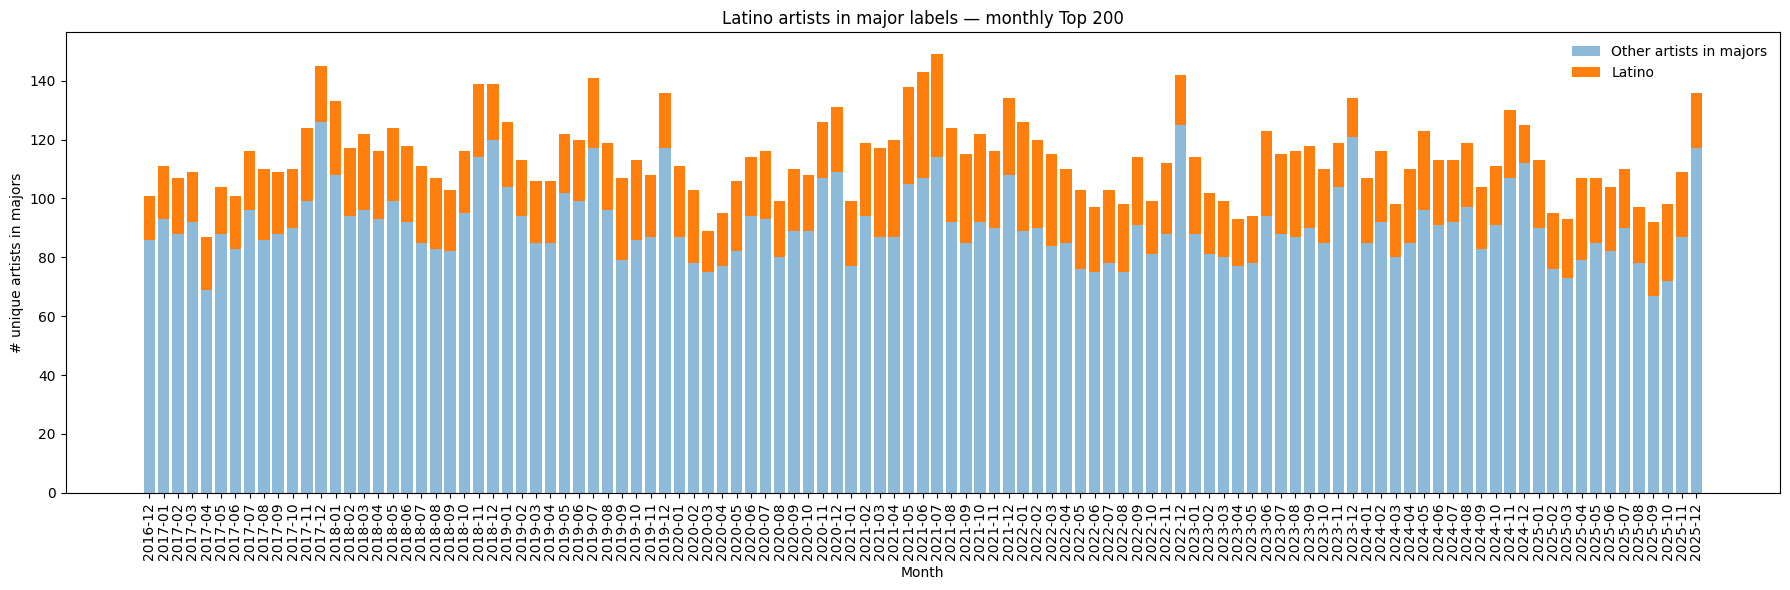

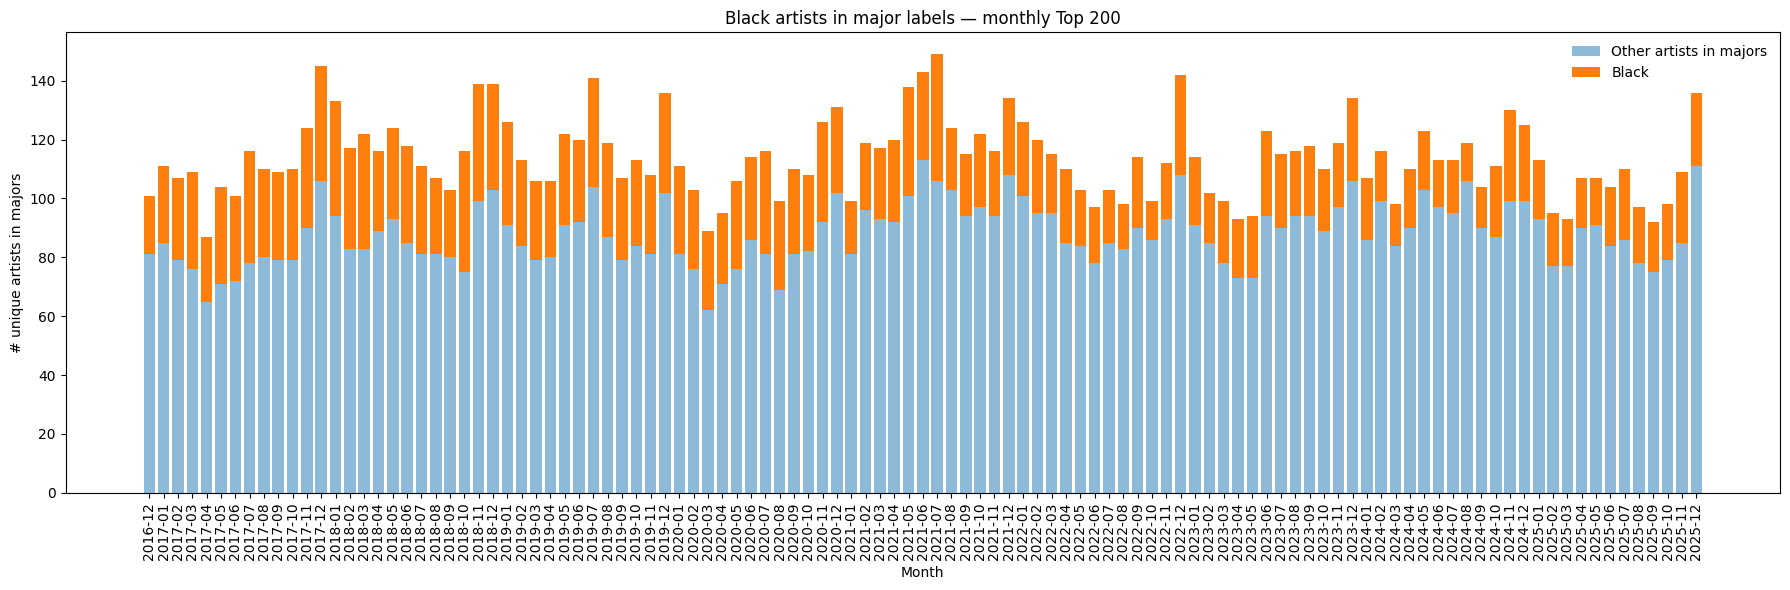

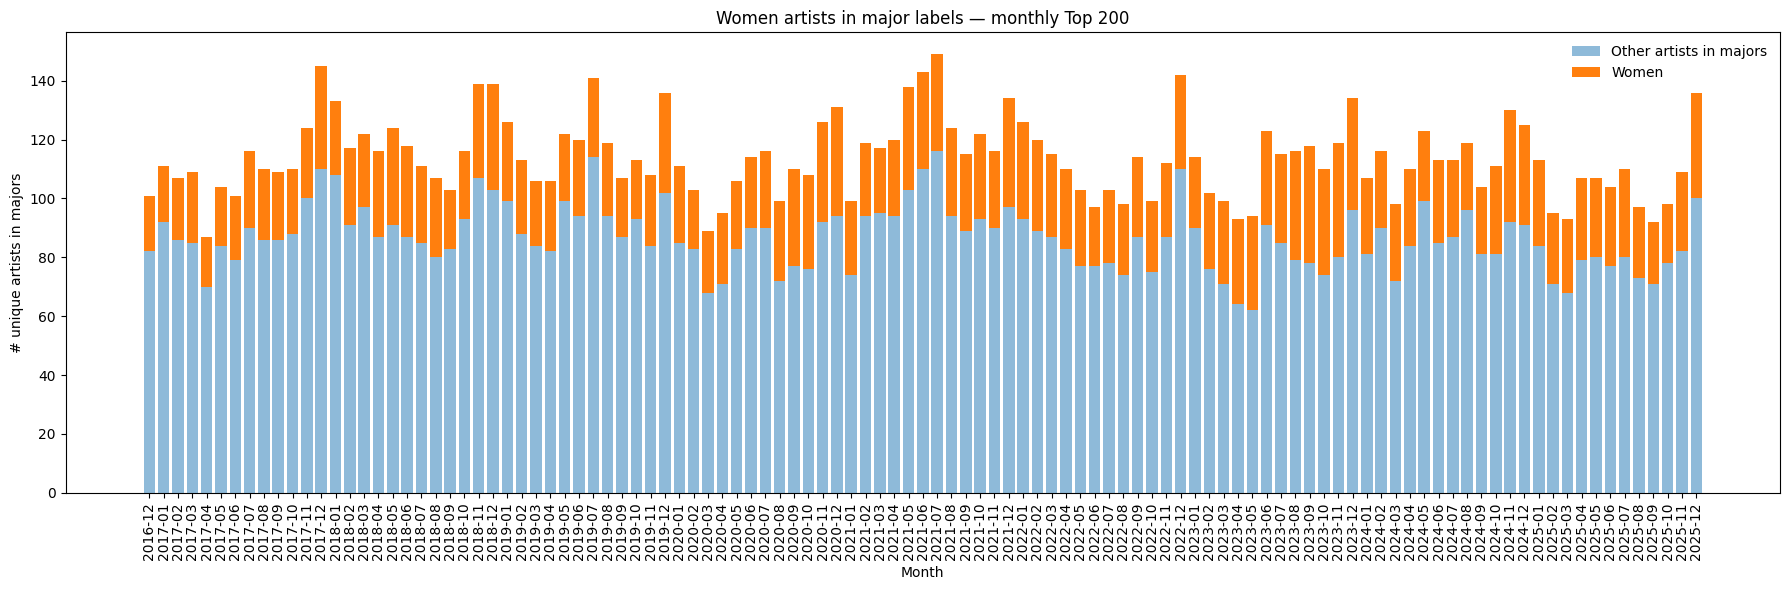

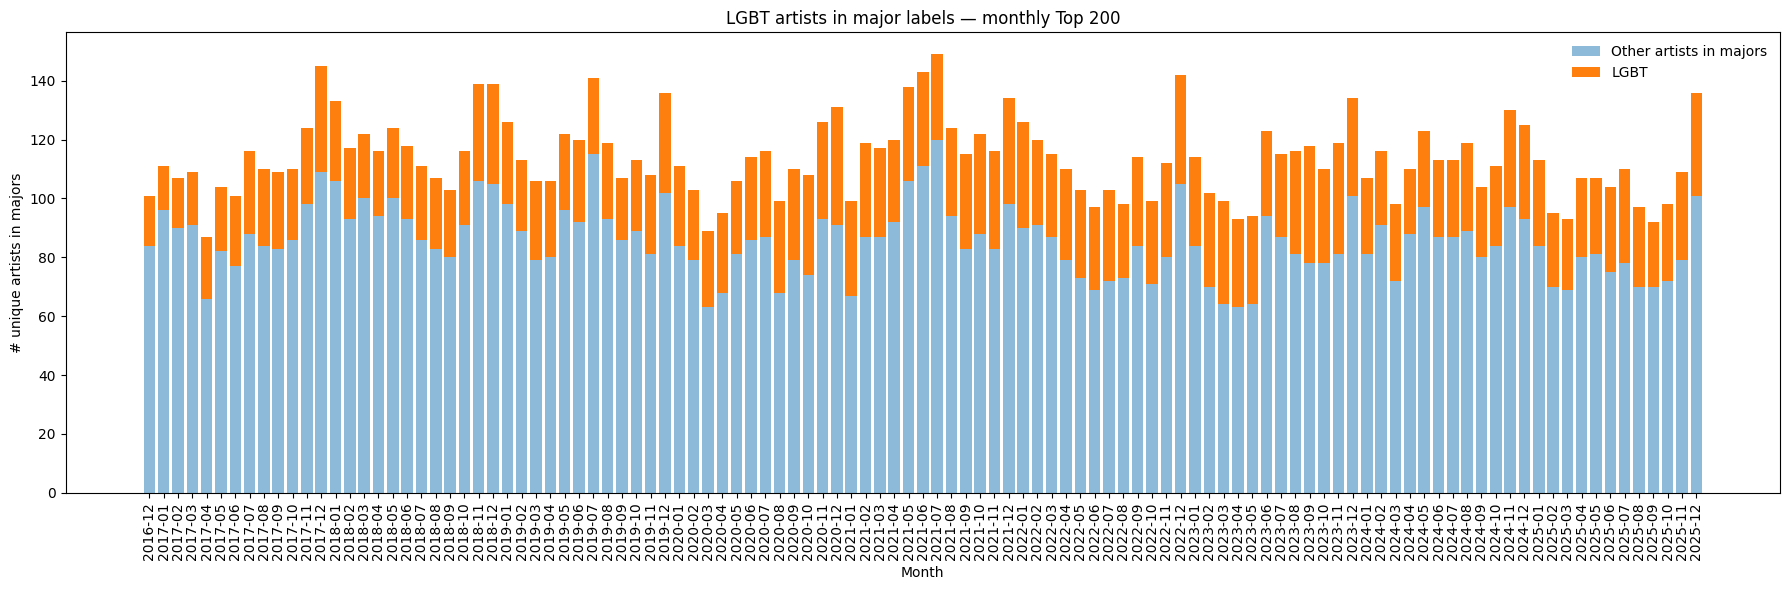

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ======================================================
# 1) Conteo mensual total de artistas en majors
# ======================================================

total_monthly = (
    maj.groupby("month")["artist_name"]
       .nunique()
       .rename("total_artists")
       .reset_index()
)

# ======================================================
# 2) Conteos por minoría
# ======================================================

def monthly_minority(flag_col, label):

    tmp = (
        maj.groupby("month")
           .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
           .rename(label)
           .reset_index()
    )

    return tmp


latino_m = monthly_minority("latino_flag", "Latino")
black_m  = monthly_minority("black_flag",  "Black")
women_m  = monthly_minority("women_flag",  "Women")
lgbt_m   = monthly_minority("lgbt_flag",   "LGBT")

# ======================================================
# 3) Merge with totals
# ======================================================

def merge_total(min_df):
    out = total_monthly.merge(min_df, on="month", how="left")
    out[label] = out[label] if False else out.iloc[:, -1]
    out.iloc[:, -1] = out.iloc[:, -1].fillna(0)
    out["Non-minority"] = out["total_artists"] - out.iloc[:, -1]
    return out


latino_df = total_monthly.merge(latino_m, on="month", how="left").fillna(0)
latino_df["Non-minority"] = latino_df["total_artists"] - latino_df["Latino"]

black_df = total_monthly.merge(black_m, on="month", how="left").fillna(0)
black_df["Non-minority"] = black_df["total_artists"] - black_df["Black"]

women_df = total_monthly.merge(women_m, on="month", how="left").fillna(0)
women_df["Non-minority"] = women_df["total_artists"] - women_df["Women"]

lgbt_df = total_monthly.merge(lgbt_m, on="month", how="left").fillna(0)
lgbt_df["Non-minority"] = lgbt_df["total_artists"] - lgbt_df["LGBT"]

# ======================================================
# 4) Plot function
# ======================================================

def plot_minority_stack(df_plot, minority):

    df_plot = df_plot.sort_values("month")

    x = np.arange(len(df_plot))

    fig, ax = plt.subplots(figsize=(18, 6))

    ax.bar(x, df_plot["Non-minority"], label="Other artists in majors", alpha=0.5)
    ax.bar(x, df_plot[minority], bottom=df_plot["Non-minority"], label=minority)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [pd.to_datetime(d).strftime("%Y-%m") for d in df_plot["month"]],
        rotation=90
    )

    ax.set_title(f"{minority} artists in major labels — monthly Top 200")
    ax.set_xlabel("Month")
    ax.set_ylabel("# unique artists in majors")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


# ======================================================
# 5) Produce the 4 figures
# ======================================================

plot_minority_stack(latino_df, "Latino")
plot_minority_stack(black_df,  "Black")
plot_minority_stack(women_df,  "Women")
plot_minority_stack(lgbt_df,   "LGBT")


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
LGBT_COL = "gay_icon"    # cámbialo si tu col se llama distinto
SMOOTH_WEEKS = 4         # ~ mensual (4 semanas)

# ---- charts: explode artists per track ----
charts = df.copy()
charts["date"] = pd.to_datetime(charts["date"], errors="coerce")
charts = charts.dropna(subset=["date"])

charts["artist_names"] = charts["artist_names"].astype(str).str.lower()
charts["artist_names"] = charts["artist_names"].str.split(",")
charts = charts.explode("artist_names")
charts["artist_names"] = charts["artist_names"].str.strip()

charts["label_clean"] = charts["label_clean"].astype(str).str.lower().str.strip()

# ---- classify majors ON charts (uses your existing is_major) ----
charts["is_major"] = charts["label_clean"].apply(is_major)

# ---- keep majors only ----
charts_major = charts[charts["is_major"]].copy()

# ---- merge with already-clean artists df (DO NOT reload artists) ----
# artists["artist_name"] should already be lower/strip from your cleaning step
merged_major = charts_major.merge(
    artists,
    left_on="artist_names",
    right_on="artist_name",
    how="left"
)

# ---- minority flags ----
merged_major["latino_flag"] = merged_major["latino_clean"].eq("yes")
merged_major["black_flag"]  = merged_major["black_clean"].eq("yes")
merged_major["women_flag"]  = merged_major["gender_clean"].eq("female")

if LGBT_COL in merged_major.columns:
    merged_major["lgbt_flag"] = merged_major[LGBT_COL].astype(str).str.lower().str.strip().eq("yes")
else:
    merged_major["lgbt_flag"] = False
    print(f"WARNING: '{LGBT_COL}' no existe en artists. Cambia LGBT_COL al nombre correcto.")


In [19]:
def weekly_unique(flag_col, out_name):
    return (
        merged_major.groupby("date")
        .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
        .rename(out_name)
        .reset_index()
    )

lat_w = weekly_unique("latino_flag", "Latino")
blk_w = weekly_unique("black_flag",  "Black")
wom_w = weekly_unique("women_flag",  "Women")
lgb_w = weekly_unique("lgbt_flag",   "LGBT")

weekly = (lat_w.merge(blk_w, on="date", how="outer")
               .merge(wom_w, on="date", how="outer")
               .merge(lgb_w, on="date", how="outer")
               .sort_values("date")
               .fillna(0))

# completar semanas (Spotify weekly suele ser jueves)
all_weeks = pd.DataFrame({"date": pd.date_range(weekly["date"].min(), weekly["date"].max(), freq="W-THU")})
weekly = all_weeks.merge(weekly, on="date", how="left").fillna(0)

# suavizado ~ mensual
for c in ["Latino", "Black", "Women", "LGBT"]:
    weekly[c + "_smooth"] = weekly[c].rolling(SMOOTH_WEEKS, min_periods=1).mean()


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/1871833723.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_17722/1871833723.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g[flag_col], "artist_name"].nunique())
/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h

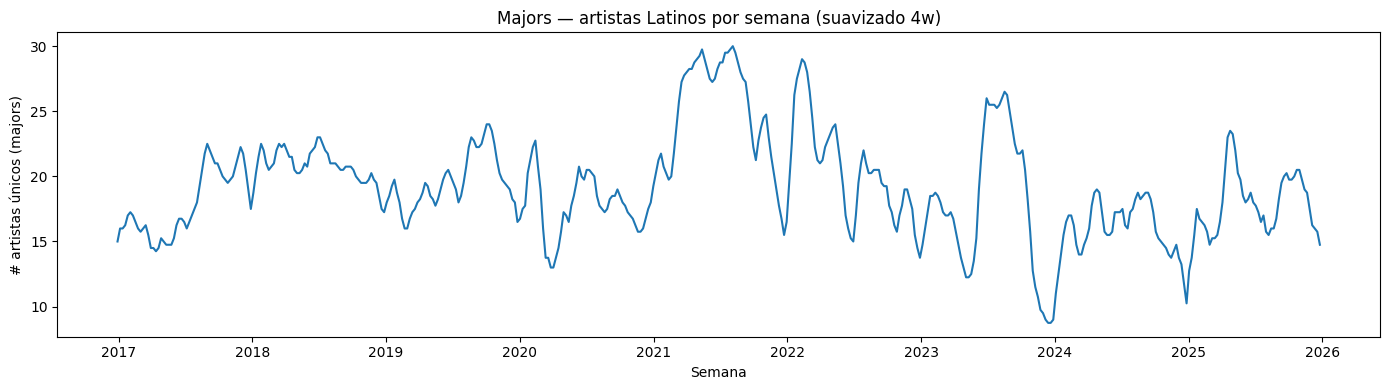

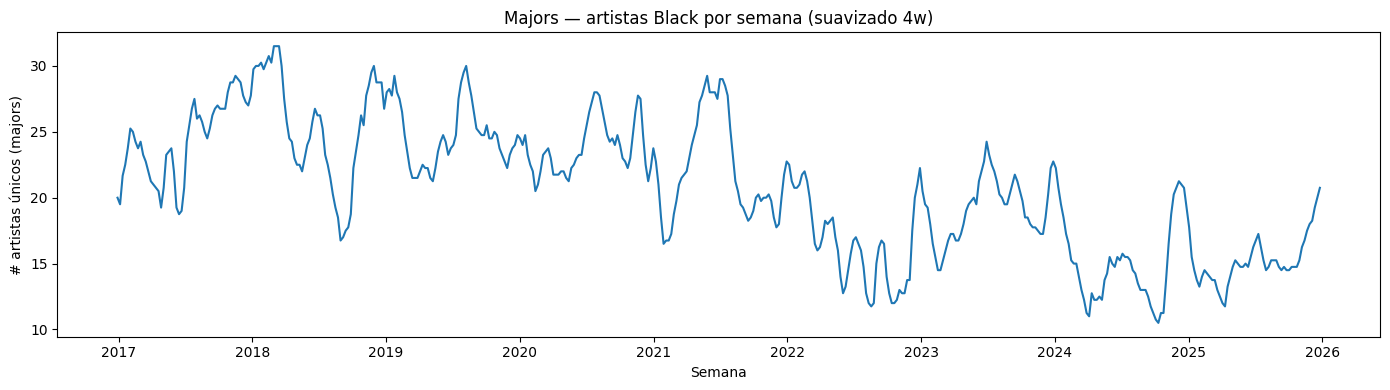

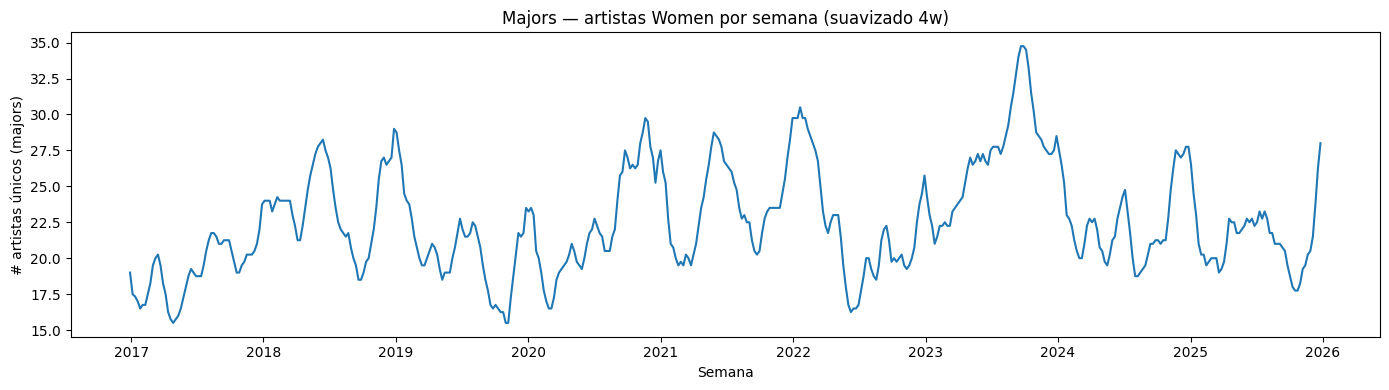

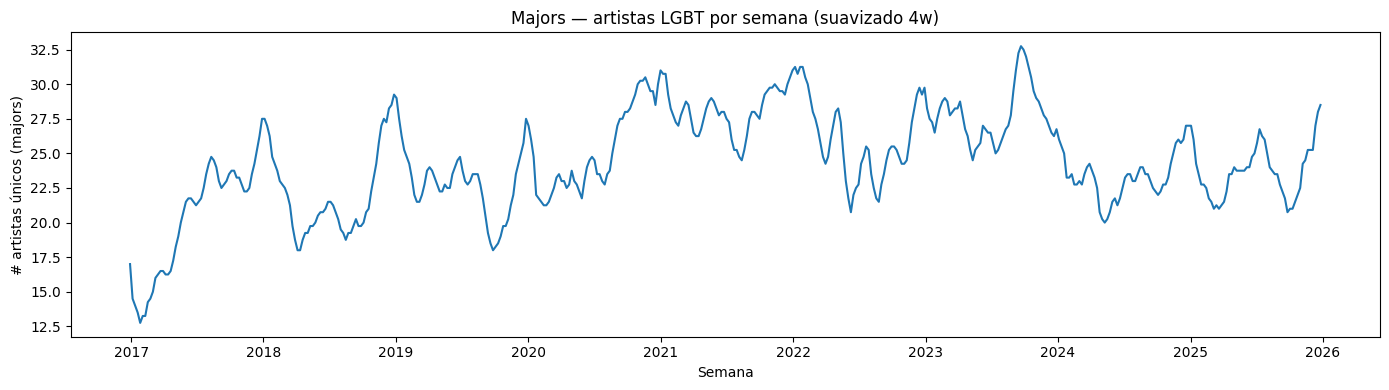

In [20]:
def plot_one(col, title):
    plt.figure(figsize=(14, 4))
    plt.plot(weekly["date"], weekly[col])
    plt.title(title)
    plt.xlabel("Semana")
    plt.ylabel("# artistas únicos (majors)")
    plt.tight_layout()
    plt.show()

plot_one("Latino_smooth", f"Majors — artistas Latinos por semana (suavizado {SMOOTH_WEEKS}w)")
plot_one("Black_smooth",  f"Majors — artistas Black por semana (suavizado {SMOOTH_WEEKS}w)")
plot_one("Women_smooth",  f"Majors — artistas Women por semana (suavizado {SMOOTH_WEEKS}w)")
plot_one("LGBT_smooth",   f"Majors — artistas LGBT por semana (suavizado {SMOOTH_WEEKS}w)")
